# Exploratory Data Analysis

**Analyst:** Shadman Arko
**Client:** Bonnie Brown — a seller who owns a typical mid-tier house in a King County "middle-class" zip code (a zip code whose median sale price falls in the 40th–60th percentile county-wide) and wants to sell within the next 6–12 months for the best possible price.

**Data:** King County home sales, filtered to the 14 zip codes that meet the "middle-class" definition above. 3,818 sales between May 2014 and May 2015, cleaned in [`04_data_cleaning.ipynb`](04_data_cleaning.ipynb) — see that notebook for how missing values, a `yr_renovated` data-entry bug, and outliers were handled.

This notebook is split into two parts:
- **Primary EDA**: a deep dive into the columns behind Bonnie's specific hypotheses (this notebook, below).
- **Secondary EDA**: a faster sanity-check sweep over the remaining columns, to make sure nothing important was missed.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams.update({"figure.figsize": (9, 5), "axes.facecolor": "white", "axes.edgecolor": "black"})
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", None)

SEASON_ORDER = ["Winter", "Spring", "Summer", "Fall"]

In [2]:
df = pd.read_csv(
    "data/bonnie_brown_middle_class_houses_clean.csv",
    parse_dates=["date"],
    dtype={"waterfront": "category", "view": "category", "condition": "category", "grade": "category", "zipcode": "category"},
)
df["sale_season"] = pd.Categorical(df["sale_season"], categories=SEASON_ORDER, ordered=True)
print(f"{df.shape[0]:,} sales across {df['zipcode'].nunique()} zip codes, {df['date'].min().date()} to {df['date'].max().date()}")
df.head()

3,818 sales across 14 zip codes, 2014-05-02 to 2015-05-13


,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,sale_count,sale_year,sale_month,sale_season,sqft_basement_was_missing,waterfront_was_missing,view_was_missing,yr_renovated_was_missing,is_renovated
0,200500410,3,2.50,1960,9535,2.00,0.0,0.0,3,8,1960,0,1989,0.00,98011,47.74,-122.22,2520,9206,2015-05-06,"575,000.00",1,2015,5,Spring,False,False,False,True,False
1,200500610,3,2.50,2600,7465,2.00,0.0,0.0,3,9,2600,0,1988,0.00,98011,47.74,-122.22,2660,7683,2014-06-11,"571,000.00",1,2014,6,Summer,False,False,False,True,False
2,200500680,3,2.50,2620,11056,2.00,0.0,0.0,3,9,2620,0,1988,0.00,98011,47.74,-122.22,2560,8688,2014-07-15,"557,500.00",1,2014,7,Summer,False,False,False,False,False
3,200500700,3,2.50,2120,9736,2.00,0.0,0.0,3,9,2120,0,1988,0.00,98011,47.74,-122.22,2490,8763,2014-06-12,"531,000.00",1,2014,6,Summer,False,False,False,True,False
4,200510060,3,2.50,2570,9487,2.00,0.0,3.0,3,9,2570,0,1989,0.00,98011,47.74,-122.22,2490,9898,2014-12-31,"605,000.00",1,2014,12,Winter,False,False,False,False,False


## Data Overview

Before testing any hypotheses, let's ground the analysis in plain numbers Bonnie can relate to: what does a "typical" house in her market look like, and what does a typical sale price look like?

In [3]:
summary = pd.DataFrame({
    "Median sale price": [f"${df['price'].median():,.0f}"],
    "Typical size": [f"{df['sqft_living'].median():.0f} sqft"],
    "Typical layout": [f"{df['bedrooms'].median():.0f} bed / {df['bathrooms'].median():.1f} bath"],
    "Typical grade (out of 13)": [f"{df['grade'].astype(int).median():.0f}"],
    "Share ever renovated": [f"{df['is_renovated'].mean():.1%}"],
}).T.rename(columns={0: "Bonnie's market, at a glance"})
summary

,"Bonnie's market, at a glance"
Median sale price,"$450,000"
Typical size,1970 sqft
Typical layout,3 bed / 2.2 bath
Typical grade (out of 13),7
Share ever renovated,2.9%


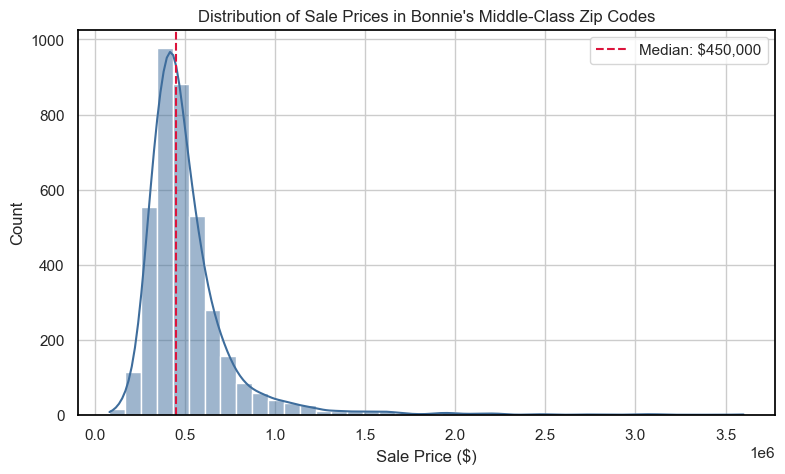

In [4]:
fig, ax = plt.subplots()
sns.histplot(df["price"], bins=40, kde=True, ax=ax, color="#3E6D9C")
ax.axvline(df["price"].median(), color="crimson", linestyle="--", label=f"Median: ${df['price'].median():,.0f}")
ax.set_title("Distribution of Sale Prices in Bonnie's Middle-Class Zip Codes")
ax.set_xlabel("Sale Price ($)")
ax.legend()
plt.show()

**What this tells Bonnie:** the median house in her market sells for about $450,000. The distribution is right-skewed (a long tail of higher-priced sales) — this is normal for house prices and is why we use the **median**, not the mean, as "typical" throughout this analysis: a handful of expensive sales would otherwise pull the "average" up and paint a misleading picture of what most houses actually sell for.

## Research Questions and Hypotheses

Given Bonnie's situation — a seller in a middle-class neighborhood, wanting to move within 6–12 months for the best possible price — these are the questions we'll answer with the data:

| # | Research Question | Hypothesis | Indicator(s) |
|---|---|---|---|
| 1 | Does *when* she lists her house affect the sale price? | The season/month of sale measurably shifts price | `sale_season`, `sale_month`, `price` |
| 2 | Does the house's condition or build grade drive price? | Higher grade/condition houses sell for more | `condition`, `grade`, `price` |
| 3 | Is renovating before selling worth it? | Renovated houses sell at a premium over comparable non-renovated ones | `is_renovated`, `yr_renovated`, `price`, `price_per_sqft` |
| 4 | Does location within the "middle-class" band matter? | Price varies meaningfully across the 14 qualifying zip codes | `zipcode`, `lat`, `long`, `price` |
| 5 | What physical feature drives price the most? | Living space (`sqft_living`) is a stronger price driver than bedroom/bathroom count | `sqft_living`, `bedrooms`, `bathrooms`, `price` |

## Hypothesis 1 — Timing: Does the season affect sale price?

Bonnie wants to move "soon" but has some flexibility — so it's worth checking whether listing in a particular season historically gets a better price.

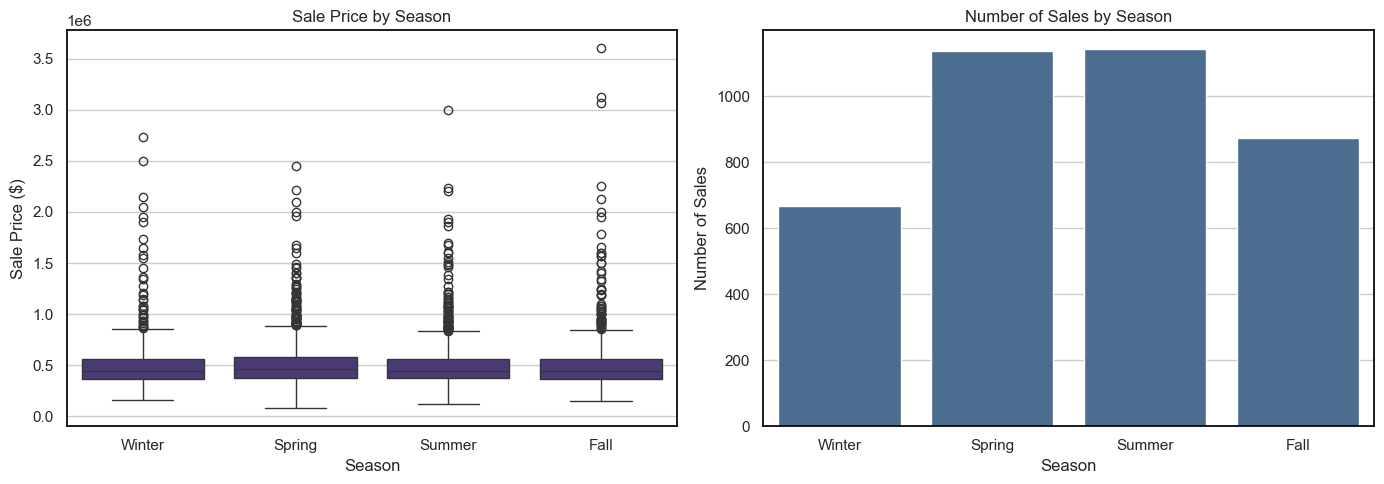

,median,mean,sales
sale_season,,,
Winter,"446,975.00","503,207.32",668
Spring,"462,750.00","514,179.45",1136
Summer,"443,000.00","503,422.82",1142
Fall,"446,375.00","510,298.02",872


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="sale_season", y="price", order=SEASON_ORDER, ax=axes[0])
axes[0].set_title("Sale Price by Season")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Sale Price ($)")

sns.countplot(data=df, x="sale_season", order=SEASON_ORDER, ax=axes[1], color="#3E6D9C")
axes[1].set_title("Number of Sales by Season")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Number of Sales")

plt.tight_layout()
plt.show()

df.groupby("sale_season", observed=True)["price"].agg(median="median", mean="mean", sales="count")

**Finding:** Spring has both the highest median price (\$462,750) and the most sales volume — it's the most active *and* the best-paying season. Winter, Summer, and Fall are close to each other (all around \$443,000–\$447,000 median), only about 3–4% lower than Spring. This is a real but **modest** effect, not a dramatic swing.

**For Bonnie:** if her 6–12 month window gives her the choice, **listing in spring (March–May)** gives a small price edge and the most buyer activity (more competing offers). But timing alone won't make or break her sale — it's a minor lever compared to the ones below.

## Hypothesis 2 — Does condition or build grade drive price?

These are two different things and it's worth separating them clearly for Bonnie:
- **`condition`** (1–5) is about upkeep — how well-maintained the house is *for its age*. This is something a seller can improve before listing (cleaning, small repairs, staging).
- **`grade`** (4–13) is King County's construction/design quality rating — largely fixed at build time (materials, workmanship, layout quality). A seller generally can't change this without a major renovation.

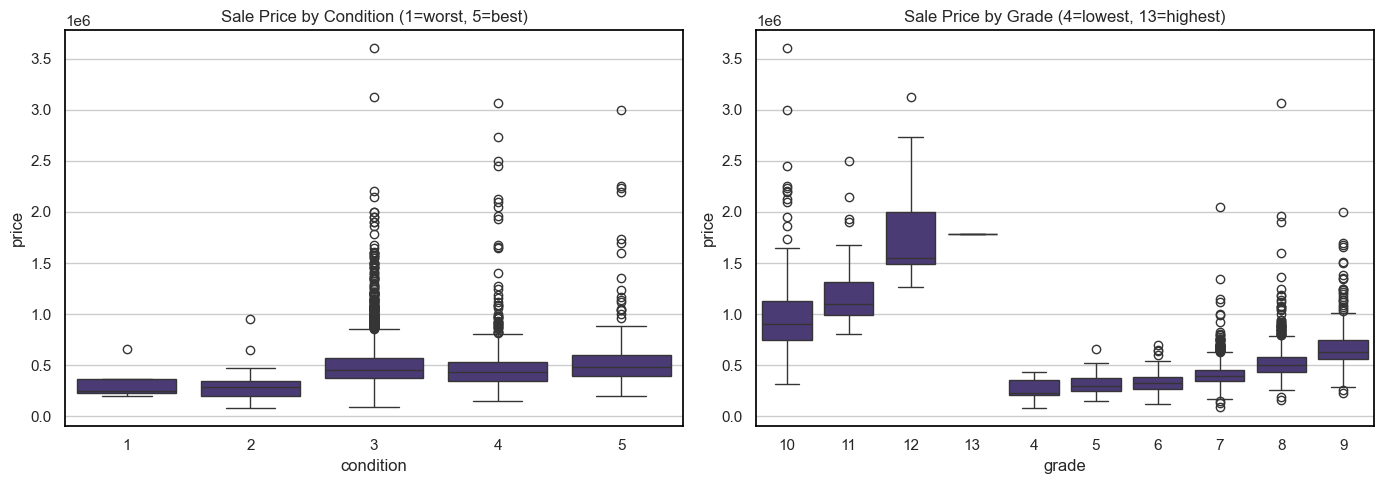

Spearman correlation — condition vs price: -0.02
Spearman correlation — grade vs price:     0.70


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="condition", y="price", ax=axes[0])
axes[0].set_title("Sale Price by Condition (1=worst, 5=best)")

sns.boxplot(data=df, x="grade", y="price", ax=axes[1])
axes[1].set_title("Sale Price by Grade (4=lowest, 13=highest)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

condition_corr = df["condition"].astype(int).corr(df["price"], method="spearman")
grade_corr = df["grade"].astype(int).corr(df["price"], method="spearman")
print(f"Spearman correlation — condition vs price: {condition_corr:.2f}")
print(f"Spearman correlation — grade vs price:     {grade_corr:.2f}")

**Finding — this is a genuinely counter-intuitive one:** `grade` correlates strongly with price (ρ ≈ 0.70) — moving from grade 7 (median \$400,000) to grade 9 (median \$635,000) is roughly a 59% jump. But `condition` barely correlates with price at all (ρ ≈ -0.02, essentially zero) — condition 5 ("best") houses don't reliably sell for more than condition 3 ("average") houses in this data.

**Why this makes sense:** buyers in this price range seem to be paying for the house's underlying construction quality and layout (grade) far more than its cosmetic upkeep (condition). A well-built house with worn paint still commands a good price; a poorly-built house with fresh paint doesn't catch up.

**For Bonnie:** this means **light cosmetic staging/repairs are unlikely to move her sale price much** — the data doesn't show a condition premium. Her price is largely already "locked in" by her house's grade, which isn't something a quick pre-sale fix-up can change. This directly informs recommendation-setting later — it tells her *not* to over-invest in cosmetic touch-ups expecting a payoff.

## Hypothesis 3 — Is renovating before selling worth it?

Renovated and non-renovated houses aren't naturally the same size, so comparing raw sale price could be misleading — a bigger house sells for more regardless of renovation. We control for this by comparing **price per square foot** (`price / sqft_living`) instead of raw price.

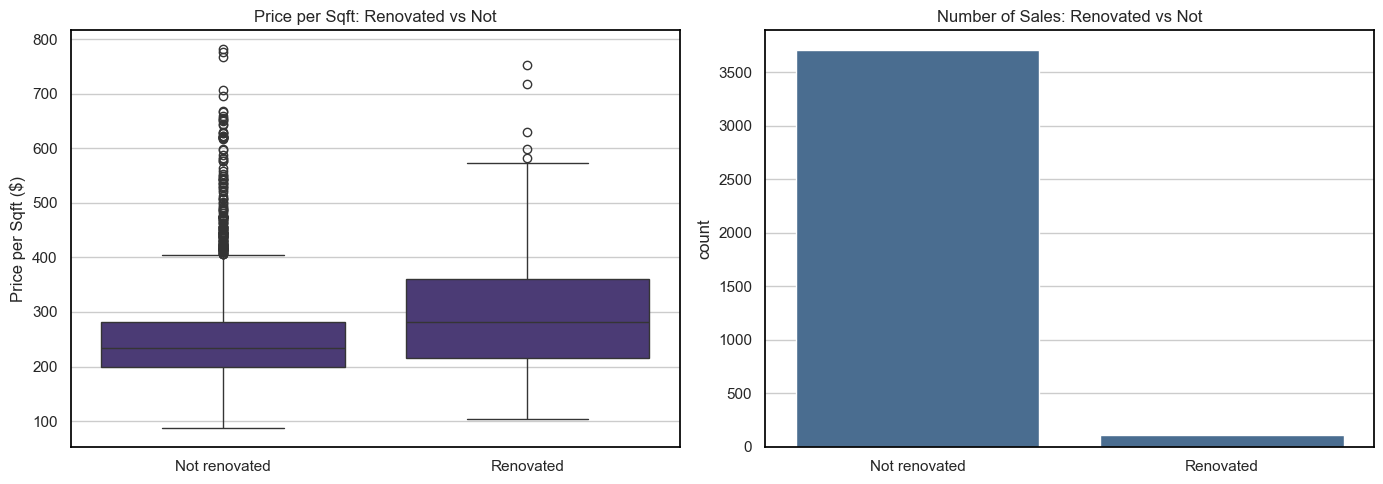

,price,price_per_sqft,sqft_living,n_sales
renovation_status,,,,
Not renovated,"449,500.00",233.30,"1,970.00",3706
Renovated,"574,500.00",282.53,"2,225.00",112


In [7]:
df["price_per_sqft"] = df["price"] / df["sqft_living"]
df["renovation_status"] = df["is_renovated"].map({True: "Renovated", False: "Not renovated"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="renovation_status", y="price_per_sqft", ax=axes[0])
axes[0].set_title("Price per Sqft: Renovated vs Not")
axes[0].set_ylabel("Price per Sqft ($)")
axes[0].set_xlabel("")

sns.countplot(data=df, x="renovation_status", ax=axes[1], color="#3E6D9C")
axes[1].set_title("Number of Sales: Renovated vs Not")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

reno_summary = df.groupby("renovation_status")[["price", "price_per_sqft", "sqft_living"]].median()
reno_summary["n_sales"] = df["renovation_status"].value_counts()
reno_summary

**Finding:** renovated houses sell for about **21% more per square foot** (\$282.53/sqft vs \$233.30/sqft) than non-renovated ones — a real, sizeable premium even after controlling for size. However, only 112 of 3,818 sales (2.9%) in this data are renovated houses, so this estimate is based on a fairly small sample and should be treated as directional, not exact.

**Caveat worth being upfront about:** this is a correlation, not a controlled experiment — renovated houses might also differ in other ways (e.g., better location, different age) that we haven't isolated here. We're not claiming renovation *causes* a guaranteed 21% bump, only that it's associated with one in this data.

**For Bonnie:** a meaningful renovation looks like it can pay off, unlike simple condition-based touch-ups (Hypothesis 2). This is a bigger, more expensive decision though — worth weighing renovation cost against a plausible price gain in the ~15–20% range, not something to decide on this chart alone.

## Hypothesis 4 — Does location matter, even within "middle-class" zip codes? (Geographical Insight)

All 14 zip codes here already qualify as "middle-class" by our county-wide definition — but that's a wide band (40th–60th percentile). It's worth checking how much they differ *from each other*.

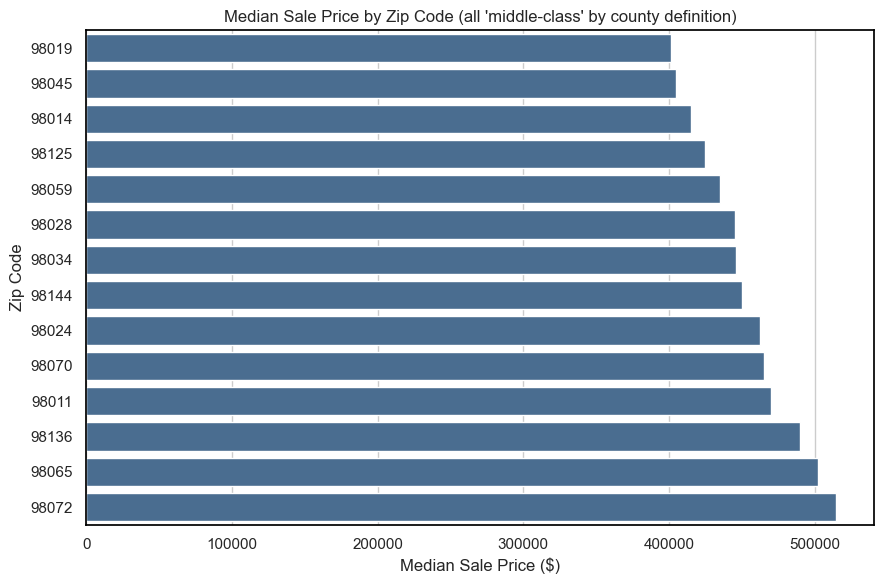

,median_price,n_sales
zipcode,,
98019,"401,250.00",190
98045,"404,750.00",220
98014,"415,000.00",124
98125,"425,000.00",409
98059,"435,000.00",468
98028,"445,000.00",283
98034,"445,950.00",545
98144,"450,000.00",343
98024,"462,500.00",80


In [8]:
zip_stats = (
    df.groupby("zipcode", observed=True)["price"]
    .agg(median_price="median", n_sales="count")
    .sort_values("median_price")
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(
    data=zip_stats.reset_index(), y="zipcode", x="median_price", order=zip_stats.index, ax=ax, color="#3E6D9C"
)
ax.set_title("Median Sale Price by Zip Code (all 'middle-class' by county definition)")
ax.set_xlabel("Median Sale Price ($)")
ax.set_ylabel("Zip Code")
plt.tight_layout()
plt.show()

zip_stats

An interactive map makes this much easier for a non-technical audience to digest than a table of zip codes — you can zoom, pan, and hover over any point.

In [9]:
import plotly.express as px

fig = px.scatter_map(
    df,
    lat="lat",
    lon="long",
    color="price",
    color_continuous_scale="Turbo",
    opacity=0.6,
    hover_name="zipcode",
    hover_data={
        "price": ":$,.0f",
        "sqft_living": True,
        "grade": True,
        "lat": False,
        "long": False,
    },
    zoom=8.8,
    height=700,
    title="House Prices Across King County"
)

fig.update_traces(marker=dict(size=7))

fig.update_layout(
    map_style="carto-positron",
    margin=dict(l=0, r=0, t=50, b=0),
    coloraxis_colorbar=dict(title="Price ($)")
)

fig.show()

**Finding:** even within this "middle-class" band, the highest-median zip code (98072, \$515,000) sells for about **28% more** than the lowest (98019, \$401,250). Looking at the map, the higher-priced zip codes cluster closer to Seattle/the water side of the county, while the lower-priced ones sit further out.

**For Bonnie:** "middle-class" is not one uniform market — where exactly her house sits matters a lot. If she's in one of the higher-median zips (98072, 98065, 98136), she's already well-positioned. If she's in a lower-median zip (98019, 98045, 98014), that's useful context to set realistic price expectations, and something no amount of staging or timing will fully offset — location is the single largest lever in this dataset that she can't change.

## Hypothesis 5 — Which physical feature drives price the most?

Bedrooms, bathrooms, and living space all plausibly relate to price. We compare their correlation strength directly.

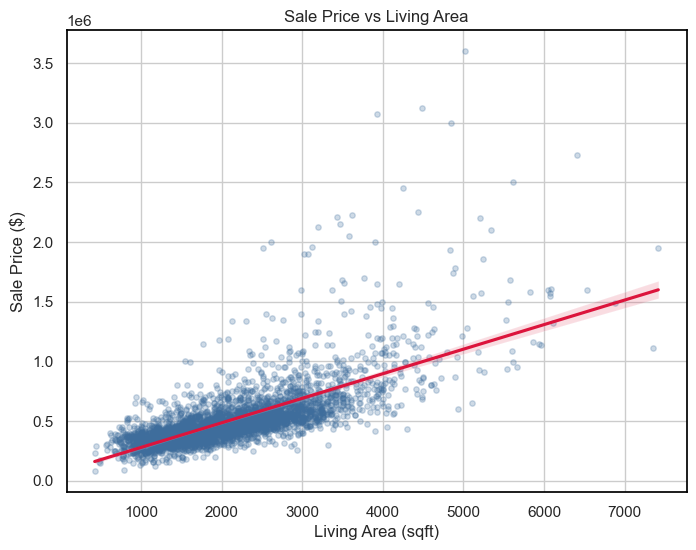

,correlation with price
sqft_living,0.71
bathrooms,0.53
bedrooms,0.30
floors,0.28


In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(
    data=df, x="sqft_living", y="price", scatter_kws={"alpha": 0.25, "s": 15, "color": "#3E6D9C"},
    line_kws={"color": "crimson"}, ax=ax,
)
ax.set_title("Sale Price vs Living Area")
ax.set_xlabel("Living Area (sqft)")
ax.set_ylabel("Sale Price ($)")
plt.show()

feature_corr = df[["sqft_living", "bedrooms", "bathrooms", "floors", "price"]].corr()["price"].drop("price").sort_values(ascending=False)
feature_corr.to_frame("correlation with price")

**Finding:** `sqft_living` is clearly the strongest physical driver of price (r ≈ 0.71), well ahead of bathrooms (r ≈ 0.53), bedrooms (r ≈ 0.30), and floors (r ≈ 0.28). This confirms the hypothesis: **living space matters more than room counts**. Two houses with the same number of bedrooms can sell for very different prices depending on how spacious those rooms are.

**For Bonnie:** if she's ever deciding between "add a bedroom" and "add square footage" (e.g., finishing a basement, adding an addition), the data says **square footage is the stronger lever** — adding a bedroom without adding usable space doesn't move price nearly as much as the space itself does.

### Hypothesis Summary — Correlation at a Glance

A focused correlation heatmap over just the columns behind our five hypotheses, to see everything side-by-side in one view.

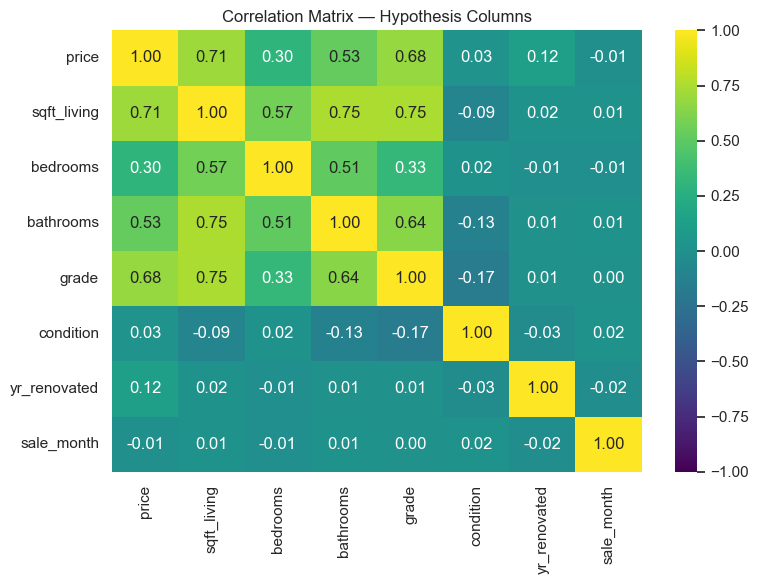

In [11]:
hypothesis_cols = ["price", "sqft_living", "bedrooms", "bathrooms", "grade", "condition", "yr_renovated", "sale_month"]
hyp_df = df[hypothesis_cols].apply(lambda s: s.astype(int) if s.dtype.name == "category" else s)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(hyp_df.corr(), annot=True, fmt=".2f", cmap="viridis", ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix — Hypothesis Columns")
plt.tight_layout()
plt.show()

---

# Secondary EDA — Remaining Columns

The five hypotheses above cover the columns most directly relevant to Bonnie's situation. This section is a faster, broader **sanity-check sweep** over everything else — `bathrooms`, `floors`, `waterfront`, `view`, the `sqft_*` size variants, `yr_built`, `sale_count`, and the `*_was_missing` flags created during cleaning. The goal here isn't a deep narrative for each one, it's to (a) confirm nothing unexpected is hiding in the columns we didn't focus on, and (b) flag anything that looks surprising enough to be worth a closer look later.

## Quick `describe()` Sanity Check

In [12]:
remaining_numeric = ["bathrooms", "floors", "sqft_lot", "sqft_above", "sqft_basement",
                     "sqft_living15", "sqft_lot15", "yr_built", "sale_count"]
df[remaining_numeric].describe()

,bathrooms,floors,sqft_lot,sqft_above,sqft_basement,sqft_living15,sqft_lot15,yr_built,sale_count
count,"3,818.00","3,818.00","3,818.00","3,818.00","3,818.00","3,818.00","3,818.00","3,818.00","3,818.00"
mean,2.15,1.52,"22,934.24","1,848.27",260.29,"2,030.86","18,500.25","1,976.43",1.01
std,0.73,0.52,"64,386.15",825.11,413.84,671.28,"43,401.95",27.41,0.12
min,0.75,1.00,676.00,420.00,0.00,460.00,824.00,"1,900.00",1.00
25%,1.75,1.00,"5,802.25","1,230.00",0.00,"1,540.00","5,899.00","1,960.00",1.00
50%,2.25,1.50,"8,312.00","1,620.00",0.00,"1,900.00","8,093.00","1,979.00",1.00
75%,2.50,2.00,"13,049.25","2,330.00",500.00,"2,410.00","11,620.00","2,001.00",1.00
max,7.50,3.00,"1,164,794.00","7,420.00","2,810.00","5,790.00","871,200.00","2,015.00",2.00


**Quick reads:**
- `sqft_lot` is heavily right-skewed — median lot is 8,312 sqft, but the mean is 22,934 sqft, pulled up by lots as large as 1.16 million sqft (~27 acres). A handful of semi-rural properties with huge lots sit inside otherwise "middle-class" zip codes — the same mean-vs-median skew lesson from the price distribution applies here too.
- `yr_built` spans **1900 to 2015** — Bonnie's market includes both century-old houses and brand-new builds selling side by side at similar prices, which is a useful thing to know if she's ever comparing her own house's age to "the market."
- Nothing here jumps out as an error (no negative values, no impossible sqft/lot/year numbers) — this is mostly confirming the cleaning held up.

## Categorical Counts: `waterfront` and `view`

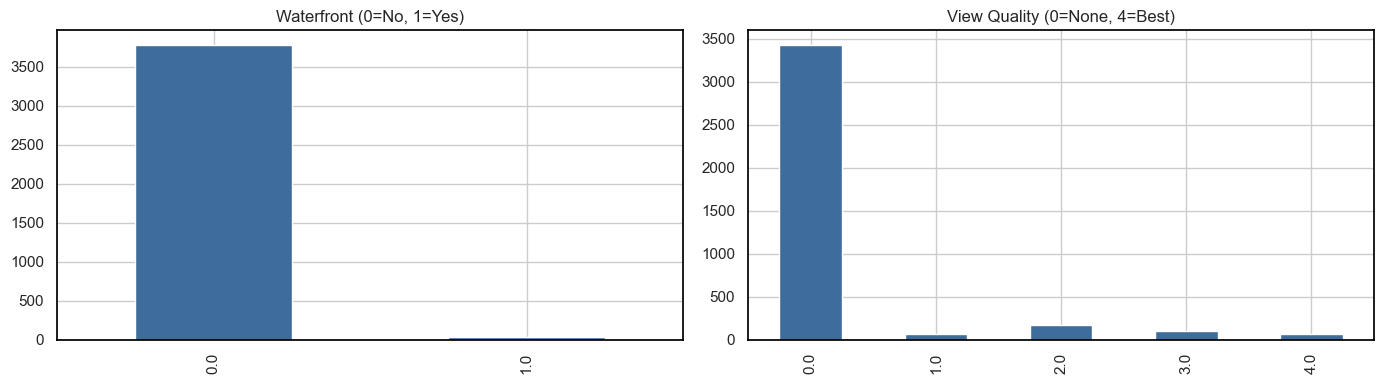

Median price -- waterfront:
waterfront
0.0     450,000.00
1.0   1,150,000.00
Name: price, dtype: float64

Median price -- view:
view
0.0     439,000.00
1.0     608,095.00
2.0     665,000.00
3.0     718,250.00
4.0   1,010,000.00
Name: price, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df["waterfront"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#3E6D9C")
axes[0].set_title("Waterfront (0=No, 1=Yes)")
axes[0].set_xlabel("")

df["view"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#3E6D9C")
axes[1].set_title("View Quality (0=None, 4=Best)")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

print("Median price -- waterfront:")
print(df.groupby("waterfront", observed=True)["price"].median())
print("\nMedian price -- view:")
print(df.groupby("view", observed=True)["price"].median())

**Worth flagging, even though it's outside Bonnie's core hypotheses:** both `waterfront` and `view` show a *much* bigger price effect than anything in the primary section — waterfront houses (only 39 of 3,818, ~1%) have a median price of \$1,150,000 vs. \$450,000 for non-waterfront, and price rises steadily with view quality, from \$439,000 (no view) up to \$1,010,000 (best view). These are rare in Bonnie's "middle-class" zip codes, which is exactly why they weren't part of the core hypotheses — but if her own house happens to have any water view, that's a meaningfully bigger price lever than anything else in this analysis, and worth a dedicated follow-up if it applies to her.

## Fast Full Correlation Heatmap

One heatmap across every numeric column in the dataset — the "fast overview" version, as opposed to the focused hypothesis-only heatmap earlier. This is purely a scan for anything unexpectedly strongly correlated that we haven't already discussed.

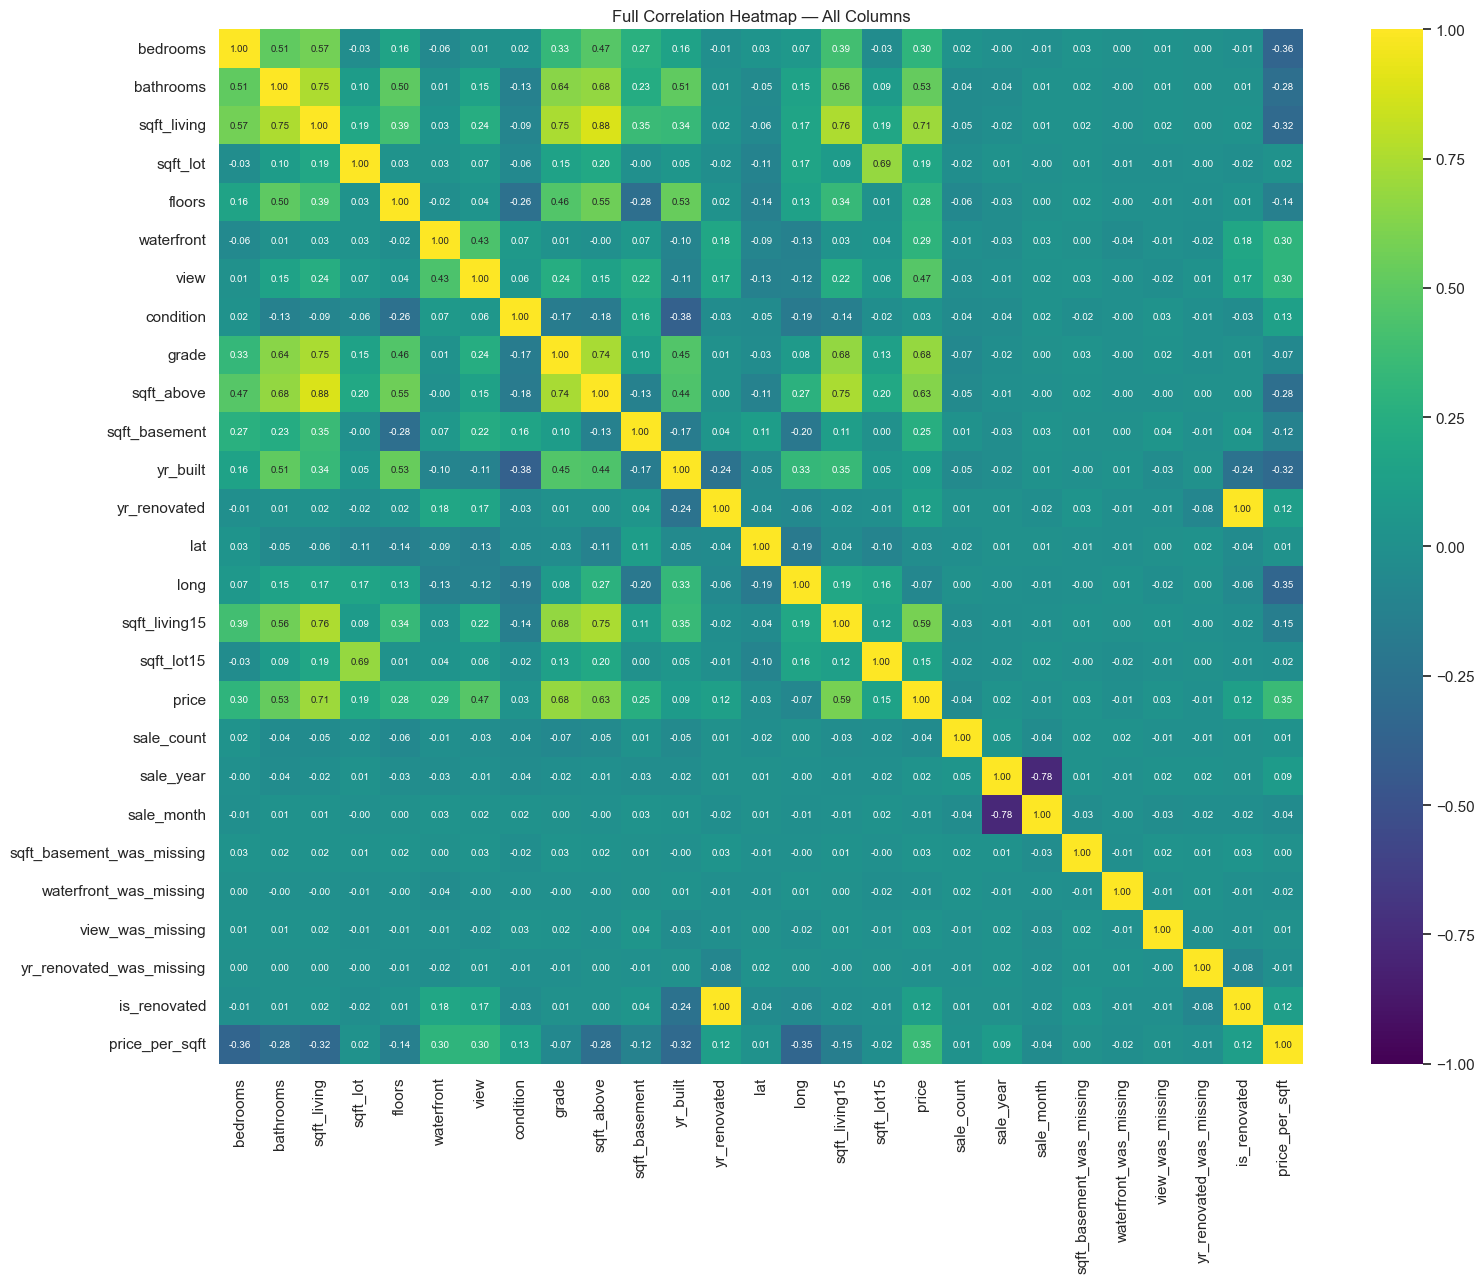

In [14]:
# zipcode is excluded here: it's a location label, not an ordered scale, so a numeric
# correlation against it would be meaningless (its geographic story is already covered
# by the zip-code bar chart and map above).
categorical_cols = ["waterfront", "view", "condition", "grade"]
full_numeric_df = df.drop(columns=["id", "date", "sale_season", "renovation_status", "zipcode"]).copy()
for col in categorical_cols:
    full_numeric_df[col] = full_numeric_df[col].astype(float).astype(int)

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(full_numeric_df.corr(), annot=True, fmt=".2f", cmap="viridis", ax=ax, vmin=-1, vmax=1, annot_kws={"size": 7})
ax.set_title("Full Correlation Heatmap — All Columns")
plt.tight_layout()
plt.show()

## Imputation Bias Check

One last check that's specifically about trusting our own cleaning: did the rows where we imputed a missing value turn out to be systematically different (in price) from the rows that already had data? If "was missing" quietly correlates with price, our fill-in choices could be distorting the analysis.

In [15]:
missing_flags = ["sqft_basement_was_missing", "waterfront_was_missing", "view_was_missing", "yr_renovated_was_missing"]

bias_check = pd.DataFrame({
    flag: df.groupby(flag)["price"].median() for flag in missing_flags
}).T
bias_check.columns = ["price_median_had_data", "price_median_was_imputed"]
bias_check["pct_difference"] = (bias_check["price_median_was_imputed"] / bias_check["price_median_had_data"] - 1) * 100
bias_check

,price_median_had_data,price_median_was_imputed,pct_difference
sqft_basement_was_missing,"450,000.00","496,500.00",10.33
waterfront_was_missing,"450,000.00","440,000.00",-2.22
view_was_missing,"450,000.00","499,950.00",11.10
yr_renovated_was_missing,"450,000.00","446,975.00",-0.67


**Result:** small differences (-2% to +11%), no dramatic split. This is reassuring — it means our imputation choices in the cleaning notebook aren't hiding a systematic bias (e.g., "all the missing-waterfront rows happen to be luxury homes"). `sqft_basement_was_missing` and `view_was_missing` show the largest gaps (~10-11%), so if this analysis were extended into predictive modeling later, those two would be worth a second look — but for descriptive EDA purposes, this is within normal noise.

## Secondary EDA — Summary

Nothing in this sweep contradicts or undermines the Primary EDA findings. The one thing worth carrying forward: **`waterfront` and `view`**, while rare in this "middle-class" dataset, show a far larger price effect than anything in the core hypotheses — worth a one-line callout in the final recommendations in case it applies to Bonnie's specific house.

---

# Insights & Recommendations for Bonnie Brown

Pulling together everything from the Primary and Secondary EDA above into what actually matters for Bonnie's decision: when to sell, whether to fix anything up first, and what to expect.

**A reminder of our operating assumption** (stated explicitly, as any analysis making assumptions about a client should): Bonnie owns a typical mid-tier house for her zip code, in one of the 14 King County zip codes whose median sale price falls in the 40th–60th percentile county-wide, and she wants to sell within 6–12 months for the best achievable price. Where a recommendation depends on *which* specific zip code her house is in, that's noted explicitly.

## Insights

**1. "Middle-class" is not one price point — location still matters a lot. (Geographical insight)**
Even within this single county-wide price tier, the highest-median zip code (98072, \$515,000) sells for **~28% more** than the lowest (98019, \$401,250). On the map, higher-priced zips cluster closer to Seattle and the water side of the county; lower-priced ones sit further out. Bonnie's exact zip code sets a large part of her price ceiling before anything else is considered.

**2. Buyers pay for construction quality, not cosmetic upkeep.**
`grade` (King County's built-in construction/design quality rating) correlates strongly with price (ρ ≈ 0.70) — moving from grade 7 to grade 9 is roughly a 59% jump in median price. `condition` (how well-kept the house is) barely correlates with price at all (ρ ≈ -0.02). A well-built house with worn paint still commands a good price; fresh paint on a lower-grade house doesn't meaningfully catch up.

**3. Living space beats room count.**
`sqft_living` is the strongest physical driver of price (r ≈ 0.71), clearly ahead of bathrooms (r ≈ 0.53), bedrooms (r ≈ 0.30), and floors (r ≈ 0.28). Two 3-bedroom houses can sell for very different prices depending on how spacious those bedrooms — and the house overall — actually are.

**4. A genuine renovation shows a real premium; timing shows only a small one.**
Renovated houses sell for **~21% more per square foot** than non-renovated ones (based on a small sample — only 112 of 3,818 sales, so treat as directional). By contrast, the *season* of sale moves price by only 3–4% (Spring is best, both for price and sales volume) — a real but minor lever compared to renovation or location.

**5. Waterfront/view access is rare in this data but by far the single biggest price lever.**
Only ~1% of houses in these middle-class zips are waterfront, yet they have a median price of \$1,150,000 — more than double the \$450,000 typical price. View quality shows the same pattern, rising steadily to \$1,010,000 for the best-rated views. This wasn't part of the core hypotheses (it's rare in a "middle-class" dataset by definition), but it's worth checking for Bonnie's specific house.

## Recommendations

**1. Set price expectations by her specific zip code, not the "middle-class" label as a whole.**
A 28% swing exists inside this one tier. Before setting an asking price, Bonnie should look at the median for her *exact* zip code (see the table/map above) rather than assuming all "middle-class" zips price similarly — this alone should shape her expectations more than anything below.

**2. Don't spend money on purely cosmetic fixes expecting a price bump.**
Condition (upkeep) showed essentially no price relationship in this data. Light painting, decluttering, and staging are still worth doing for a *faster* sale and better first impressions, but Bonnie shouldn't expect them to move her sale price — that budget is better spent elsewhere (see #3) or not spent at all if funds are limited.

**3. If budget and timeline allow, a genuine renovation is the one improvement lever that shows a real payoff.**
Historically, renovated houses sold for ~21% more per square foot. Given her 6–12 month window, a renovation (kitchen, bath, or structural) is feasible timing-wise. That said: get contractor quotes and weigh the cost against a *plausible* 15–20% gain — this estimate comes from a small sample (112 houses) and isn't a guarantee.

**4. When adding space, prioritize square footage over bedroom count.**
If Bonnie is considering any addition or basement finish before selling, the data says usable living space matters far more to price than an extra bedroom on its own — don't add a bedroom by subdividing existing space; add net new square footage if anything.

**5. If she has any flexibility, list in spring (March–May).**
It's a modest lever (3–4%) compared to the others, but it's free — spring also brought the most sales activity in this data, meaning more competing buyers and potentially faster offers, which fits her "wants to move soon" goal well.

**6. Check if her house has any water proximity or view — and if so, make it the headline of the listing.**
This is the single largest price factor found in the entire analysis, even though it wasn't a core hypothesis for a "middle-class" seller. If it applies to her house at all, it should dominate the marketing, ahead of every recommendation above.

---

### A note on limits of this analysis
This EDA is descriptive, not causal — the renovation and grade effects are strong associations, not proof that renovating *will* deliver exactly a 21% gain for any specific house. Sample sizes for renovated (112) and waterfront (39) houses are small relative to the full dataset. For a decision as large as a house sale, these findings are best used to prioritize *where* to focus (location, renovation, listing timing) rather than as precise price guarantees.